In [3]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


Mon, 27 Oct 2025 18:08:26 +0000


TypeError: 'module' object is not callable

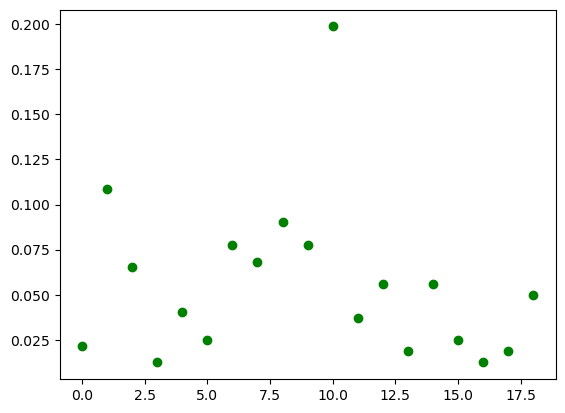

In [12]:
import numpy as np
import pandas as pd
import scipy as sp
import  pickle
from scipy import fft
from time import localtime, strftime
import matplotlib.pyplot as plt
from skimage.morphology import  disk,remove_small_objects
from skimage.filters.rank import gradient
from skimage.util import img_as_ubyte 
import wave

###########################
# Folder Name Setting
###########################
folder = 'J:/DATAMINING/KAGGLE/MLSP_BirdClassification/'


essential_folder = 'essential_data/'
supplemental_folder = 'supplemental_data/'
spectro_folder =folder+'/spectograms2/'
single_spectro_folder =folder+'my_spectro_single/'
# dp_folder = folder+'DP/'

###################################################
## Read the Essential Data 
## labels, training-test split,file_names etc.
###################################################

# Each audio file has a unique recording identifier ("rec_id"), ranging from 0 to 644. 
# The file rec_id2filename.txt indicates which wav file is associated with each rec_id.
rec2f = pd.read_csv(essential_folder + 'rec_id2filename.txt', sep = ',')

# There are 19 bird species in the dataset. species_list.txt gives each a number from 0 to 18. 
species = pd.read_csv(essential_folder + 'species_list.txt', sep = ',')
num_species = 19

# The dataset is split into training and test sets. 
# CVfolds_2.txt gives the fold for each rec_id. 0 is the training set, and 1 is the test set.
cv =  pd.read_csv(essential_folder + 'CVfolds_2.txt', sep = ',')

# This is your main label training data. For each rec_id, a set of species is listed. The format is:
# rec_id,[labels]
raw =  pd.read_csv(essential_folder + 'rec_labels_test_hidden.txt', sep = ';')
label = np.zeros(len(raw)*num_species)
label = label.reshape([len(raw),num_species])
for i in range(len(raw)):
    line = raw.iloc[i]  # Use iloc[] instead of iloc()
    # Get the first column value and convert to string
    line_str = str(line.iloc[0]) if hasattr(line, 'iloc') else str(line[0])
    labels = line_str.split(',')
    labels.pop(0) # rec_id == i
    for c in labels:
        if(c != '?'):
            label[i,int(c)] = 1  # Convert c to int

label = pd.DataFrame(label)
label['rec_id'] = cv.rec_id
label['fold'] = cv.fold
label['filename'] = rec2f.filename

# Sparse training set 
# training species 1%--5%--20% 
spec_avg = label[label.fold ==0][range(num_species)].mean()
spec_avg.sort_values()
plt.plot(spec_avg,'go')

# Read the audio files 
# /src_wavs
# This folder contains the original wav files for the dataset (both training and test sets). 
# These are 10-second mono recordings sampled at 16kHz, 16 bits per sample.


def pic_to_ubyte (pic):
    a = (pic-np.min(pic) ) /(np.max(pic - np.min(pic))) 
    a = img_as_ubyte(a)
    return a


# Parameters to create the spectrogram
N = 160000
K = 512
Step = 4
wind =  0.5*(1 -np.cos(np.array(range(K))*2*np.pi/(K-1) ))
ffts = []


def wav_to_floats(filename):
    s = wave.open(filename,'r')
    strsig = s.readframes(s.getnframes())
    y = np.frombuffer(strsig, np.short)  # Changed from np.fromstring to np.frombuffer
    s.close()
    return y

 
###############################
## Create the Spectrograms
## Train + Test
###############################  
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
for file_idx in range(len(label)):
    test_flag = label.iloc[file_idx]['fold']  # Changed from irow() to iloc[]
    fname = label.iloc[file_idx]['filename']  # Changed from irow() to iloc[]
    species_on_pic = []
    for n in range(num_species):
        if(label.iloc[file_idx][n] > 0):  # Changed from irow() to iloc[]
            species_on_pic.append(n)
    
    S =  wav_to_floats(essential_folder+'src_wavs/'+fname+'.wav')
    Spectogram = []
    for j in range(int(Step*N/K)-Step):
        vec = S[j * K//Step : (j+Step) * K//Step] * wind  # Changed K/Step to K//Step for integer division
        Spectogram.append(abs(fft(vec,K)[:K//2]))  # Changed K/2 to K//2
    
    ffts.append(np.array(Spectogram))


print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
SPEC_SEGMENTS = []
LOG_SPEC_SEGMENTS = []
MIN_SEGMENT_SIZE = 99
p = 90
#fig = plt.figure(figsize=(20, 10))   

for file_idx in range(len(label)):
    test_flag = label.iloc[file_idx]['fold']  # Changed from irow() to iloc[]
    fname = label.iloc[file_idx]['filename']  # Changed from irow() to iloc[]
    species_on_pic = []
    for n in range(num_species):
        if(label.iloc[file_idx][n] > 0):  # Changed from irow() to iloc[]
            species_on_pic.append(n)
    
    label_count = label.iloc[file_idx][range(num_species)].sum()  # Changed from irow() to iloc[]
    bird_spec = label.iloc[file_idx][range(num_species)].argmax() # first bird, Changed from irow() to iloc[]
    
    if(test_flag < 1  and label_count ==1):
        mypic = np.transpose(ffts[file_idx])
        mypic_rev = np.zeros_like(mypic)
        for i in range(mypic.shape[0]):
            mypic_rev[i] = mypic[-i - 1]
        
        mypic_rev_small = mypic_rev[:200,:]
        mypic_rev = mypic_rev_small
        mypic_rev_log = np.log10(mypic_rev+ 0.001)
        mypic_rev_gauss =sp.ndimage.gaussian_filter(mypic_rev, sigma=3)
        mypic_rev_log_gauss = sp.ndimage.gaussian_filter(mypic_rev_log, sigma=3)
        mypic_rev_gauss_bin = mypic_rev_gauss > np.percentile(mypic_rev_gauss,p)
        mypic_rev_log_gauss_bin = mypic_rev_log_gauss > np.percentile(mypic_rev_log_gauss,p)
        mypic_rev_gauss_bin_close =sp.ndimage.binary_closing( sp.ndimage.binary_opening(mypic_rev_gauss_bin))
        mypic_rev_log_gauss_bin_close =sp.ndimage.binary_closing( sp.ndimage.binary_opening(mypic_rev_log_gauss_bin))
        mypic_rev_gauss_grad = gradient(pic_to_ubyte(mypic_rev_gauss), disk(3))
        mypic_rev_log_gauss_grad = gradient(pic_to_ubyte(mypic_rev_log_gauss), disk(3))
        mypic_rev_gauss_grad_bin = mypic_rev_gauss_grad > np.percentile(mypic_rev_gauss_grad,p)
        mypic_rev_log_gauss_grad_bin = mypic_rev_log_gauss_grad > np.percentile(mypic_rev_log_gauss_grad,p )
        mypic_rev_gauss_grad_bin_close =sp.ndimage.binary_closing( sp.ndimage.binary_opening(mypic_rev_gauss_grad_bin))
        mypic_rev_log_gauss_grad_bin_close =sp.ndimage.binary_closing( sp.ndimage.binary_opening(mypic_rev_log_gauss_grad_bin))
        bfh = sp.ndimage.binary_fill_holes(mypic_rev_gauss_grad_bin_close)        
        bfh_rm = remove_small_objects(bfh, MIN_SEGMENT_SIZE)
        log_bfh = sp.ndimage.binary_fill_holes(mypic_rev_log_gauss_grad_bin_close)        
        log_bfh_rm = remove_small_objects(log_bfh, MIN_SEGMENT_SIZE)      
        
#        plt.subplot(6,2,1)
#        plt.imshow(mypic_rev,cmap=plt.cm.afmhot_r)
#        plt.axis('off')
#        plt.title('Spectrogram')
#        plt.subplot(6,2,2)
#        plt.imshow(mypic_rev_log,cmap=plt.cm.afmhot_r)
#        plt.axis('off')
#        plt.title('Spectrogram (log)')       
#        plt.subplot(6,2,3)
#        plt.imshow(mypic_rev_log_gauss,cmap=plt.cm.afmhot_r)
#        plt.axis('off')
#        plt.title('+ Gaussian Filtering')
#        plt.subplot(6,2,4)
#        plt.imshow(mypic_rev_log,cmap=plt.cm.afmhot_r)
#        plt.axis('off')
#        plt.title('+ Gaussian Filtering (log)')        
#        plt.subplot(6,2,5)
#        plt.imshow(mypic_rev_gauss_grad,cmap=plt.cm.afmhot_r)
#        plt.axis('off')
#        plt.title('+ Gradient')
#        plt.subplot(6,2,6)
#        plt.imshow(mypic_rev_log_gauss_grad,cmap=plt.cm.afmhot_r)
#        plt.axis('off')
#        plt.title('+ Gradient (log)')    
#        plt.subplot(6,2,7)
#        plt.imshow(mypic_rev_gauss_grad_bin,cmap=plt.cm.gray)
#        plt.axis('off')
#        plt.title('+ >90%')
#        plt.subplot(6,2,8)
#        plt.imshow(mypic_rev_log_gauss_grad_bin,cmap=plt.cm.gray)
#        plt.axis('off')
#        plt.title('+ >90% (log)')          
#        plt.subplot(6,2,9)
#        plt.imshow(mypic_rev_gauss_grad_bin_close,cmap=plt.cm.gray)
#        plt.axis('off')
#        plt.title('+ binary_closing + binary_opening')
#        plt.subplot(6,2,10)
#        plt.imshow(mypic_rev_log_gauss_grad_bin_close,cmap=plt.cm.gray)
#        plt.axis('off')
#        plt.title('+ binary_closing + binary_opening (log)')    
        
        #SEGMENTS
        labeled_segments, num_seg = sp.ndimage.label(bfh_rm)
#        plt.subplot(6,2,11)
#        plt.imshow(labeled_segments)
#        plt.axis('off')
#        plt.title('+ binary_fill_holes + remove_small_objects')
        for current_segment_id in range(1,num_seg+1):
            current_segment = (labeled_segments == current_segment_id)*1
            xr = current_segment.max(axis =  0)
            yr = current_segment.max(axis =  1)
            xr_max = np.max(xr*np.arange(len(xr)))
            xr[xr==0] = xr.shape[0]
            xr_min = np.argmin(xr)
            yr_max = np.max(yr*np.arange(len(yr)))
            yr[yr==0] = yr.shape[0]
            yr_min = np.argmin(yr)
            segment_frame = [yr_min, yr_max, xr_min, xr_max]
            subpic = mypic_rev_gauss[yr_min:yr_max+1,xr_min:xr_max+1]
            SPEC_SEGMENTS.append([file_idx, current_segment_id, segment_frame, subpic])
        
        # LOG SEGMENTS
        labeled_segments, num_seg = sp.ndimage.label(log_bfh_rm)
#        plt.subplot(6,2,12)
#        plt.imshow(labeled_segments)
#        plt.axis('off')
#        plt.title('+ binary_fill_holes + remove_small_objects (log)')        
        for current_segment_id in range(1,num_seg+1):
            current_segment = (labeled_segments == current_segment_id)*1
            xr = current_segment.max(axis =  0)
            yr = current_segment.max(axis =  1)
            xr_max = np.max(xr*np.arange(len(xr)))
            xr[xr==0] = xr.shape[0]
            xr_min = np.argmin(xr)
            yr_max = np.max(yr*np.arange(len(yr)))
            yr[yr==0] = yr.shape[0]
            yr_min = np.argmin(yr)
            segment_frame = [yr_min, yr_max, xr_min, xr_max]
            subpic = mypic_rev_log_gauss[yr_min:yr_max+1,xr_min:xr_max+1]
            LOG_SPEC_SEGMENTS.append([file_idx, current_segment_id, segment_frame, subpic])        
        
        #fig.savefig(single_spectro_folder+str(bird_spec)+'_'+fname+'_patterns.png',dpi = 300)
        #fig.clear()
        #plt.show()

print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

## CHECK THE SEGMENTS: 
#N = 10
#fig = plt.figure(figsize=(20, 10)) 
#for i in range(N):
#    for j in range(N):
#        plt.subplot(N,N,i*N+j)
#        plt.imshow( SPEC_SEGMENTS[i*N+j][3])
#
#
#N = 10
#fig = plt.figure(figsize=(20, 10)) 
#for i in range(N):
#    for j in range(N):
#        plt.subplot(N,N,i*N+j)
#        plt.imshow( LOG_SPEC_SEGMENTS[-(i*N+j)][3],cmap=plt.cm.afmhot_r)
#
#a = []
#for r in SPEC_SEGMENTS:
#    a.append(r[2][1] - r[2][0] )
#
#plt.hist(a)

# output = open(dp_folder + 'SPEC_SEGMENTS.pkl', 'wb')
# pickle.dump(SPEC_SEGMENTS, output)
# output.close()   

# output = open(dp_folder + 'LOG_SPEC_SEGMENTS.pkl', 'wb')
# pickle.dump(LOG_SPEC_SEGMENTS, output)
# output.close()   